In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [78]:
df= pd.read_csv("loan_approval_data.csv")

In [80]:
df.info()
# Doing binary classification on loan_approval using Nieve B., Logistic R., kNN 
# Also there are only to types of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

#Handeling missing values

In [83]:
# Sorting the data ,by there datatypes 
catagorial_col= df.select_dtypes(include=["object"]).columns 
numerical_col= df.select_dtypes(include=["float64"]).columns # we can use "number" instead of float64 to include all kind of numerical datatypes

In [85]:
from sklearn.impute import SimpleImputer
num_imp= SimpleImputer(strategy="mean") # making an obj.
df[numerical_col]= num_imp.fit_transform(df[numerical_col]) # fit_tranform will give mean to num_imp(imputer) to fill the places with that mean

In [87]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [89]:
cat_imp= SimpleImputer(strategy="most_frequent") # most_frequent is mode
df[catagorial_col]= cat_imp.fit_transform(df[catagorial_col])

In [91]:
df.head() #you can clearly see the nan's are now filled

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


EDA - Exploratory Data Analysis 

Text(0.5, 1.0, 'Is loan approved')

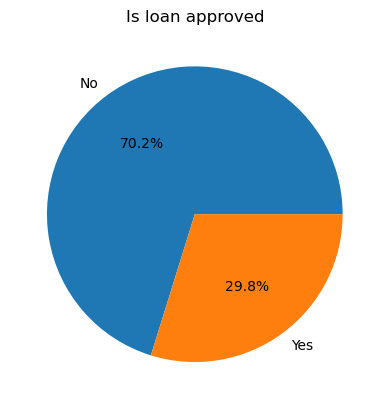

In [94]:
# how balanced our class are?

class_count= df["Loan_Approved"].value_counts()
plt.pie(class_count, labels=["No","Yes"], autopct="%1.1f%%") # Used no first as labels take input as for 0 then for 1
plt.title("Is loan approved")

<Axes: xlabel='Applicant_Income', ylabel='Count'>

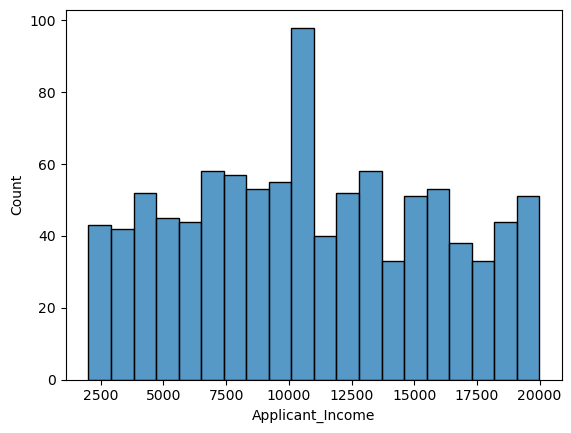

In [96]:
# Most important thing affecting the loan approval is income

sns.histplot(
    data=df,
    x= "Applicant_Income",
    bins=20
)


<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

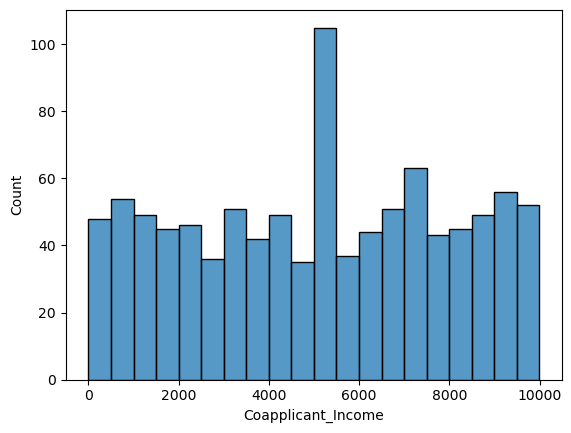

In [98]:
sns.histplot(
    data=df,
    x= "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

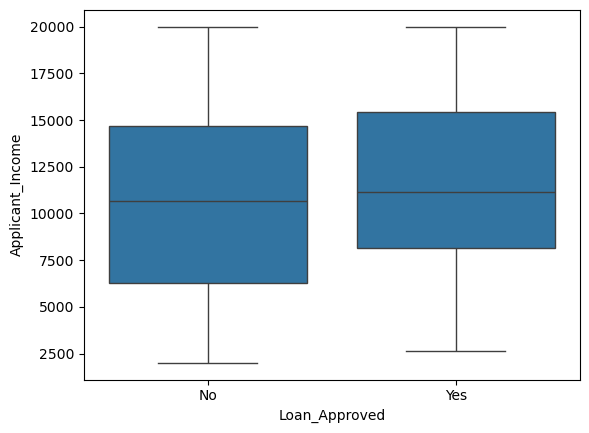

In [100]:
# using box-plot for outliers
sns.boxplot(
    data=df,
    x= "Loan_Approved",
    y= "Applicant_Income"
)